# Data Migration: SQL Sever to Postgres

In [79]:
import os
import pandas as pd
import pyodbc
import psycopg2
from psycopg2.extras import execute_values
from dotenv import load_dotenv 

## Load Credentials

In [80]:
load_dotenv() # Load environment variables from .env file

True

In [81]:
sql_host = os.getenv("SQL_SERVER_HOST")
sql_db = os.getenv("SQL_SERVER_DB")


In [82]:
print(f"SQL Server Host: {sql_host}")
print(f"SQL Server Database: {sql_db}")

SQL Server Host: DESKTOP-E4RGOJ4\SQLEXPRESS
SQL Server Database: TransactionDB_UAT


In [83]:
pg_host = os.getenv("POSTGRES_HOST")
pg_port = os.getenv("POSTGRES_PORT")
pg_db = os.getenv("POSTGRES_DB")
pg_user = os.getenv("POSTGRES_USER")
pg_password = os.getenv("POSTGRES_PASSWORD")
print(f"PostgreSQL Host: {pg_host}")
print(f"PostgreSQL Port: {pg_port}")
print(f"PostgreSQL Database: {pg_db}")
print(f"PostgreSQL User: {pg_user}")
print(f"PostgreSQL Password: {pg_password}")

PostgreSQL Host: localhost
PostgreSQL Port: 5432
PostgreSQL Database: TransactionDB_UAT
PostgreSQL User: postgres
PostgreSQL Password: 123456


## Connect to SQL Server

In [84]:
print("Connecting to SQL Server...")
print(f"SQL Server Host: {sql_host}")
print(f"SQL Server Database: {sql_db}")

Connecting to SQL Server...
SQL Server Host: DESKTOP-E4RGOJ4\SQLEXPRESS
SQL Server Database: TransactionDB_UAT


In [85]:
try:
    sql_conn_string = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={sql_host};"
    f"DATABASE={sql_db};"
    f"Trusted_Connection=yes;"
    )
    sql_cursor = sql_conn_string.cursor()
    print("Connected to SQL Server successfully.")
except Exception as e:
    print(f"Error connecting to SQL Server: {e}")

    

Connected to SQL Server successfully.


## Connect to PostgreSQL

In [86]:
try:
    pg_conn = psycopg2.connect(
        host=pg_host,
        port=pg_port,
        database=pg_db,
        user=pg_user,
        password=pg_password  
    )
    pg_cursor = pg_conn.cursor()
    pg_cursor.execute("SELECT version();")
    db_version = pg_cursor.fetchone()[0]
    print("Connected to PostgreSQL successfully.")
    print(f"PostgreSQL version: {db_version}...\n")
except psycopg2.Error as e:
    print(f"Error connecting to PostgreSQL: {e}")

Connected to PostgreSQL successfully.
PostgreSQL version: PostgreSQL 18.6 on x86_64-windows, compiled by msvc-19.44.35228, 64-bit...



## Define the tables to migrate
- Category (no dependencies)
- Suppliers (no dependencies)
- Customers (no dependencies)
- Products (no dependencies)

In [87]:
tables_to_migrate = ['Categories', 'Suppliers', 'Customers', 'Products']
print(f"Tables to migrate: {tables_to_migrate}")

Tables to migrate: ['Categories', 'Suppliers', 'Customers', 'Products']


In [88]:
print("Tables to migrate: ")
for i, table in enumerate(tables_to_migrate, start=1):
    print(f"{i}. {table}")
print("Total tables to migrate: ", len(tables_to_migrate))

Tables to migrate: 
1. Categories
2. Suppliers
3. Customers
4. Products
Total tables to migrate:  4


## Run pre-migration check

In [89]:
baseline_counts = {}
try:
    for table in tables_to_migrate:
        row_count_query = f"SELECT COUNT(*) as total_rows FROM {table}"
        sql_cursor.execute(row_count_query)
        count = sql_cursor.fetchone()[0]
        baseline_counts[table] = count

        print(f"{table:15} {count:>12} rows")

    total_rows = sum(baseline_counts.values())
    print(f"{'-' * 30}")
    print(f"{'Total':15} {total_rows:>12,} rows")
    print("\n baseline captured successfully...\n")
except Exception as e:
    print(f"Error occurred while fetching baseline counts: {e}")
    raise

Categories                 8 rows
Suppliers               5000 rows


Customers             900000 rows
Products              150000 rows
------------------------------
Total              1,055,008 rows

 baseline captured successfully...



In [90]:
quality_issues = []
try:
    sql_cursor.execute(""" SELECT COUNT(*) AS total_nulls
                           FROM CUSTOMERS
                           WHERE CustomerName IS NULL""")
    null_name = sql_cursor.fetchone()[0]
    if null_name > 0:
        quality_issues.append(f" Null Name {null_name} ")
    # print(quality_issues)


    sql_cursor.execute("""SELECT COUNT(*) AS invalid_emails 
                          FROM CUSTOMERS 
                          WHERE Email LIKE '%@invalid'""")
    invalid_email = sql_cursor.fetchone()[0]
    if invalid_email > 0:
        quality_issues.append(f" Email Error {invalid_email}")
    # print(quality_issues)


    sql_cursor.execute("""SELECT COUNT(*) AS negative_product_prices_count
                          FROM PRODUCTS
                          WHERE UNITPRICE < 0""")
    negative_prices = sql_cursor.fetchone()[0]
    if negative_prices > 0:
        quality_issues.append(f"Negative_Prices {negative_prices}")
    # print(quality_issues)


    sql_cursor.execute("""SELECT COUNT(*) AS negative_product_quantily_count
                          FROM PRODUCTS
                          WHERE STOCKQUANTITY < 0""")
    negative_quantity = sql_cursor.fetchone()[0]
    if negative_quantity > 0:
        quality_issues.append(f"Negative_Quantity {negative_quantity}")
    # print(quality_issues)

    sql_cursor.execute("""SELECT
                           COUNT(*) AS ORPHANED_RECORDS
                           FROM PRODUCTS PROD
                           WHERE NOT EXISTS(
                           SELECT 1 FROM SUPPLIERS SUP
                           WHERE SUP.SUPPLIERID=PROD.SUPPLIERID)""")
    orphaned_foreigns = sql_cursor.fetchone()[0]
    if orphaned_foreigns > 0:
        quality_issues.append(f"orphaned_foreigns {orphaned_foreigns}")
    # print(quality_issues)


    sql_cursor.execute("""SELECT COUNT(*) AS FUTURE_DATES_COUNT
                          FROM CUSTOMERS
                          WHERE CREATEDDATE > GETDATE()""")
    future_dates = sql_cursor.fetchone()[0]
    if future_dates > 0:
        quality_issues.append(f" future_dates {future_dates}")
    # print(quality_issues)

    sql_cursor.execute("""SELECT 
    COUNT(*) AS SoPhoneBiLoi
                FROM Customers
                WHERE 
                    REPLACE(
                        REPLACE(
                            REPLACE(
                                REPLACE(
                                    REPLACE(Phone, '+', ''),
                                '-', ''),
                            '(', ''),
                        ')', ''),
                    ' ', '') LIKE '%[^0-9]%'""")
    phone_error = sql_cursor.fetchone()[0]
    if phone_error > 0:
        quality_issues.append(f" Phone Error {phone_error}")

    if quality_issues:
        print("Data quality issues found (will migrate as-is)")
        for issue in quality_issues:
            print(issue)
    else:
        print("No data quality issues identfied!")


except Exception as e:
    print(f"Error occurred while checking for NULL values in Customers table: {e}")
    raise

Data quality issues found (will migrate as-is)
 Null Name 4514 
 Email Error 8844
Negative_Prices 775
Negative_Quantity 1467
orphaned_foreigns 24700
 future_dates 8851
 Phone Error 612018


In [91]:
table_schema = {}

try:

    for table in tables_to_migrate:

        schema_query = f"""
        SELECT
            COLUMN_NAME,
            DATA_TYPE,
            CHARACTER_MAXIMUM_LENGTH,
            IS_NULLABLE
        FROM INFORMATION_SCHEMA.COLUMNS
        WHERE TABLE_SCHEMA = 'dbo'
          AND TABLE_NAME = '{table}'
        ORDER BY ORDINAL_POSITION
        """

        schema_df = pd.read_sql(
            schema_query,
            sql_conn_string
        )

        print(f"\n{table}")
        print("-" * 20)
        print(schema_df)

        table_schema[table] = schema_df

except Exception as e:
    print("Error:", e)


Categories
--------------------
    COLUMN_NAME DATA_TYPE  CHARACTER_MAXIMUM_LENGTH IS_NULLABLE
0    CategoryID       int                       NaN          NO
1  CategoryName  nvarchar                      50.0         YES
2   Description  nvarchar                      -1.0         YES

Suppliers
--------------------
    COLUMN_NAME DATA_TYPE  CHARACTER_MAXIMUM_LENGTH IS_NULLABLE
0    SupplierID       int                       NaN          NO
1  SupplierName  nvarchar                     150.0         YES
2   ContactName  nvarchar                     100.0         YES
3       Country  nvarchar                     100.0         YES
4         Phone  nvarchar                      20.0         YES

Customers
--------------------
    COLUMN_NAME DATA_TYPE  CHARACTER_MAXIMUM_LENGTH IS_NULLABLE
0    CustomerID       int                       NaN          NO
1  CustomerName  nvarchar                     100.0         YES
2         Email  nvarchar                     100.0         YES
3      

C:\Users\nguye\AppData\Local\Temp\ipykernel_19636\93310391.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(
C:\Users\nguye\AppData\Local\Temp\ipykernel_19636\93310391.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(
C:\Users\nguye\AppData\Local\Temp\ipykernel_19636\93310391.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(
C:\Users\nguye\AppData\Local\Temp\ipykernel_19636\93310391.py:19: UserWarning: pandas only supports SQLAlchemy connect

In [92]:
type_mapping = {
    'int': 'INTEGER',
    'bigint': 'BIGINT',
    'smallint': 'SMALLINT',
    'tinyint': 'SMALLINT',
    'bit': 'BOOLEAN',
    'decimal': 'NUMERIC',
    'numeric': 'NUMERIC',
    'money': 'NUMERIC(19,4)',
    'smallmoney': 'NUMERIC(10,4)',
    'float': 'DOUBLE PRECISION',
    'real': 'REAL',
    'datetime': 'TIMESTAMP',
    'datetime2': 'TIMESTAMP',
    'smalldatetime': 'TIMESTAMP',
    'date': 'DATE',
    'time': 'TIME',
    'char': 'CHAR',
    'varchar': 'VARCHAR',
    'nchar': 'CHAR',
    'nvarchar': 'VARCHAR',
    'text': 'TEXT',
    'ntext': 'TEXT'
}

In [93]:
for sql_type, pg_type in list(type_mapping.items()):
    print(f"{sql_type} -->  {pg_type}")

int -->  INTEGER
bigint -->  BIGINT
smallint -->  SMALLINT
tinyint -->  SMALLINT
bit -->  BOOLEAN
decimal -->  NUMERIC
numeric -->  NUMERIC
money -->  NUMERIC(19,4)
smallmoney -->  NUMERIC(10,4)
float -->  DOUBLE PRECISION
real -->  REAL
datetime -->  TIMESTAMP
datetime2 -->  TIMESTAMP
smalldatetime -->  TIMESTAMP
date -->  DATE
time -->  TIME
char -->  CHAR
varchar -->  VARCHAR
nchar -->  CHAR
nvarchar -->  VARCHAR
text -->  TEXT
ntext -->  TEXT


In [94]:
try:
    for table in tables_to_migrate:
        schema = table_schema[table]
        pg_table = table.lower()
        pg_cursor.execute(f"DROP TABLE IF EXISTS {pg_table} CASCADE")
        column_definition = []
        for idx, row in schema.iterrows():
            col_name = row['COLUMN_NAME'].lower()
            sql_type = row['DATA_TYPE']
            base_type = sql_type.lower()
            pg_type = type_mapping.get(base_type, 'TEXT')

            conditione_1 = idx == 0
            conditione_2 = col_name.endswith('id')
            conditione_3 = 'int' in sql_type.lower()

            if conditione_1 and conditione_2 and  conditione_3:
                column_definition.append(f"{col_name} SERIAL PRIMARY KEY")
            else:
                column_definition.append(f"{col_name} {pg_type}")
        column_string = ",\n  ".join(column_definition)
        create_query= f"""CREATE TABLE {pg_table} ({column_string})"""
        pg_cursor.execute(create_query)
        pg_conn.commit()
        print("All tables created successfully")

except psycopg2.Error as e:
    print(f"Postgres experienced an error while creating a table: {e}")
    pg_conn.rollback()   
except Exception as e:
    print(f"Unexpected issue: {e}")            

All tables created successfully
All tables created successfully
All tables created successfully
All tables created successfully


In [95]:
test_table = 'Customers'
pg_table = test_table.lower()

In [96]:
try:
    print("1. read from SQL Sever...")
    extrat_query = f"SELECT * FROM {pg_table}"
    test_df = pd.read_sql(extrat_query, sql_conn_string)
    print(f"Read {len(test_df)} row")

    print("2. Tranfroming data type from SQL Sever...")
    if 'IsActive' in test_df.columns:
        test_df['IsActive'] = test_df['IsActive'].astype('bool')
        print("[SUCCESS] --> Converted IsActive: BIT ---> BOOLEAN")

    print("3. Prepare the data for loading")
    data_tuples = [tuple(row) for row in test_df.to_numpy()]

    columns = [col.lower() for col in test_df.columns]
    columns_string = ',  '.join(columns)
    placeholders =',  '.join(['%s'] * len(columns))
    insert_query = f"""INSERT INTO {pg_table} ({columns_string}) VALUES %s"""
    print(f"   Prepared{len(data_tuples)} row")

    print("4. Insert data into PostgerSQL...")
    execute_values(pg_cursor, insert_query, data_tuples, page_size=1000)
    pg_conn.commit()
    print(f"loaded{len(data_tuples): ,} rows")

    print("5. Verifying...")
    pg_cursor.execute(f"SELECT COUNT(*) AS total_rows FROM {pg_table}")
    pg_count = pg_cursor.fetchone()[0]
    sql_count = baseline_counts[test_table]

    if pg_count == sql_count:
        print(f"[SUCCESS] --> Verificatione passed: {pg_count:,} == {sql_count:,}")
    else:
        print(f"[FAILED] --> Count mismatch: {pg_count:,} != {sql_count}")

    print(f"\n {test_table} migration test successfully completed!")

except Exception as e:
    pg_conn.rollback()
    print(f"[ERROR] Migration failed: {e}")

C:\Users\nguye\AppData\Local\Temp\ipykernel_19636\1914093418.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test_df = pd.read_sql(extrat_query, sql_conn_string)


1. read from SQL Sever...
Read 900000 row
2. Tranfroming data type from SQL Sever...
[SUCCESS] --> Converted IsActive: BIT ---> BOOLEAN
3. Prepare the data for loading
   Prepared900000 row
4. Insert data into PostgerSQL...
loaded 900,000 rows
5. Verifying...
[SUCCESS] --> Verificatione passed: 900,000 == 900,000

 Customers migration test successfully completed!


In [97]:
remaining_table = [t for t in tables_to_migrate if t!= 'Customers']

for table in remaining_table:
    pg_table = table.lower()
    print(f"Migrating{table}--> {pg_table}...")

try:
    print("1. Reading from SQL Sever...")
    except_query = f"SELECT * FROM {table}"
    sql_df = pd.read_sql(except_query, sql_conn_string)
    print(f"Read {len(sql_df):,} row \n")

    print("2. Preparing data..")
    data_tuples = [tuple(row) for row in sql_df.to_numpy()]
    column = [col.lower() for col in sql_df.columns]
    column_string = ',  '.join(column)
    insert_query = f"""INSERT INTO {pg_table} ({column_string}) VALUES %s"""
    print(f"   Prepared{len(data_tuples)} row")
    
    print("3. Proocessing Bulk load...")
    execute_values(pg_cursor, insert_query, data_tuples, page_size=1000)
    pg_conn.commit()
    print(f"loaded{len(data_tuples): ,} rows")
    
    print("4. Verifying...")
    pg_cursor.execute(f"SELECT COUNT(*) AS total_rows FROM {pg_table}")
    pg_count = pg_cursor.fetchone()[0]
    sql_count = baseline_counts[table]
    
    if pg_count == sql_count:
        print(f"[SUCCESS] --> Verificatione passed: {pg_count:,} == {sql_count:,}")
    else:
        print(f"[FAILED] --> Count mismatch: {pg_count:,} != {sql_count}")
    
    print(f"\n {table} migration test successfully completed!")
    
except Exception as e:
        pg_conn.rollback()
        print(f"[ERROR] Migration failed: {e}")
    

MigratingCategories--> categories...
MigratingSuppliers--> suppliers...
MigratingProducts--> products...
1. Reading from SQL Sever...


C:\Users\nguye\AppData\Local\Temp\ipykernel_19636\3129653354.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sql_df = pd.read_sql(except_query, sql_conn_string)


Read 150,000 row 

2. Preparing data..
   Prepared150000 row
3. Proocessing Bulk load...
loaded 150,000 rows
4. Verifying...
[SUCCESS] --> Verificatione passed: 150,000 == 150,000

 Products migration test successfully completed!


## Run post-migration validation
--1. Row counts checks
SUCCESS: MATCHES SQL SERVER

-- 2. Data type checks
SUCCESS: MATCHES SQL SERVER

--3. Primary key checks (duplicates)
SUCCESS:MATCHES SQL SERVER

--4. Referential integrity checks (duplicates)
SUCCESS: MATCHES SQL SERVER

AttributeError: Rectangle.set() got an unexpected keyword argument 'lable'

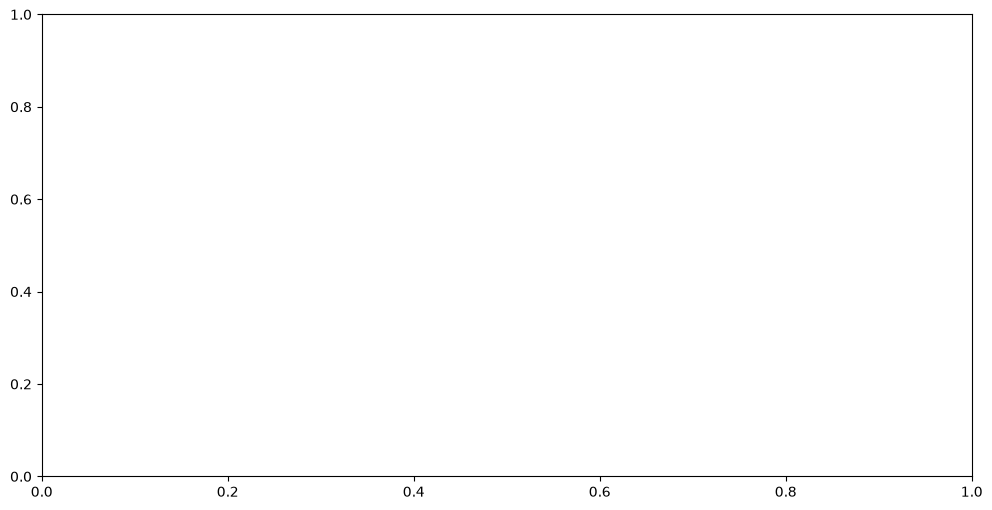

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(12,6))

table_names = tables_to_migrate
sql_counts = [baseline_counts[t] for t in tables_to_migrate]

pg_count = []

for table in tables_to_migrate:
    pg_cursor.execute(f"SELECT COUNT(*) FROM {table.lower()}")
    pg_count.append(pg_cursor.fetchone()[0])
    x = range(len(table_names))
    width = 0.35

    bars1 = ax.bar([i - width/2 for i in x],
                   sql_count,
                   width,
                   label="SQL Server",
                   color="#2e86ab",
                   alpha = 0.8)
    bars2 = ax.bar([i - width/2 for i in x],
                       sql_count,
                       width,
                       label="Postgres",
                       color="#06a77d",
                       alpha = 0.8)

ax.set_xlable('Table', fontweight='bold', fontsize = 12)
ax.set_title('Migration validationl: SQL Server to Postgres', fontweight = 'bold', fontsize= 14)
ax.set_xticks(x)
ax.set_xticklabels(table_names)

ax.get_yaxis().set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_yscale('log')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:

        height = bar.get_height()
        label = f"{int(height/1000)}K" if height >= 1000 else f'{int(height)}'

        ax.text(bar.get_x() + bar.get_width()/2,
                height * 1.1,
                label,
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold')

plt.tight_layout()
plt.show()
